### RideWise --- Exploratory Data Analysis (ED)

### STEP 1 Setup & Imports

In [6]:
# import Libraries
import os 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# configurations (renders plots directly in the notebook i.e inline)
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline     
sns.set_theme(style="whitegrid", font_scale= 1.1)
plt.rcParams.update({"figure.dpi":110, "axes.spines.top":False, "axes.spines.right":False})


### STEP 2 Loading the Data

In [7]:
# Load the dataset
riders= pd.read_csv(r"C:\Users\colge\OneDrive\Downloads\Ridewise_London-Gbolahan\data\raw\riders.csv", parse_dates=["signup_date"])
trips =pd.read_csv(r"C:\Users\colge\OneDrive\Downloads\Ridewise_London-Gbolahan\data\raw\trips.csv")
drivers=pd.read_csv(r"C:\Users\colge\OneDrive\Downloads\Ridewise_London-Gbolahan\data\raw\drivers (1).csv", parse_dates=["signup_date"])
sessions=pd.read_csv(r"C:\Users\colge\OneDrive\Downloads\Ridewise_London-Gbolahan\data\raw\sessions.csv")
promotions=pd.read_csv(r"C:\Users\colge\OneDrive\Downloads\Ridewise_London-Gbolahan\data\raw\promotions (1).csv")



In [8]:
# Quick Data Overview

for name, df, in [("riders", riders),("trips",trips), ("drivers", drivers),("sessions", sessions)
                  , ("promotions", promotions)]:
                print( f"{name:<12} {df.shape[0]:>7} rows {df.shape[1]:>2} cols")

riders         10000 rows  8 cols
trips         200000 rows 16 cols
drivers         5000 rows  7 cols
sessions       50000 rows  8 cols
promotions        20 rows 11 cols


In [9]:
## Inspection of riders data sheet
print(riders.dtypes)
print(riders.isnull().sum())
riders.head()

user_id                     object
signup_date         datetime64[ns]
loyalty_status              object
age                        float64
city                        object
avg_rating_given           float64
churn_prob                 float64
referred_by                 object
dtype: object
user_id                0
signup_date            0
loyalty_status         0
age                    0
city                   0
avg_rating_given       0
churn_prob             0
referred_by         6947
dtype: int64


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,NaN
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002


### STEP 3 Visualisation of Riders (Showing Data Distribution)

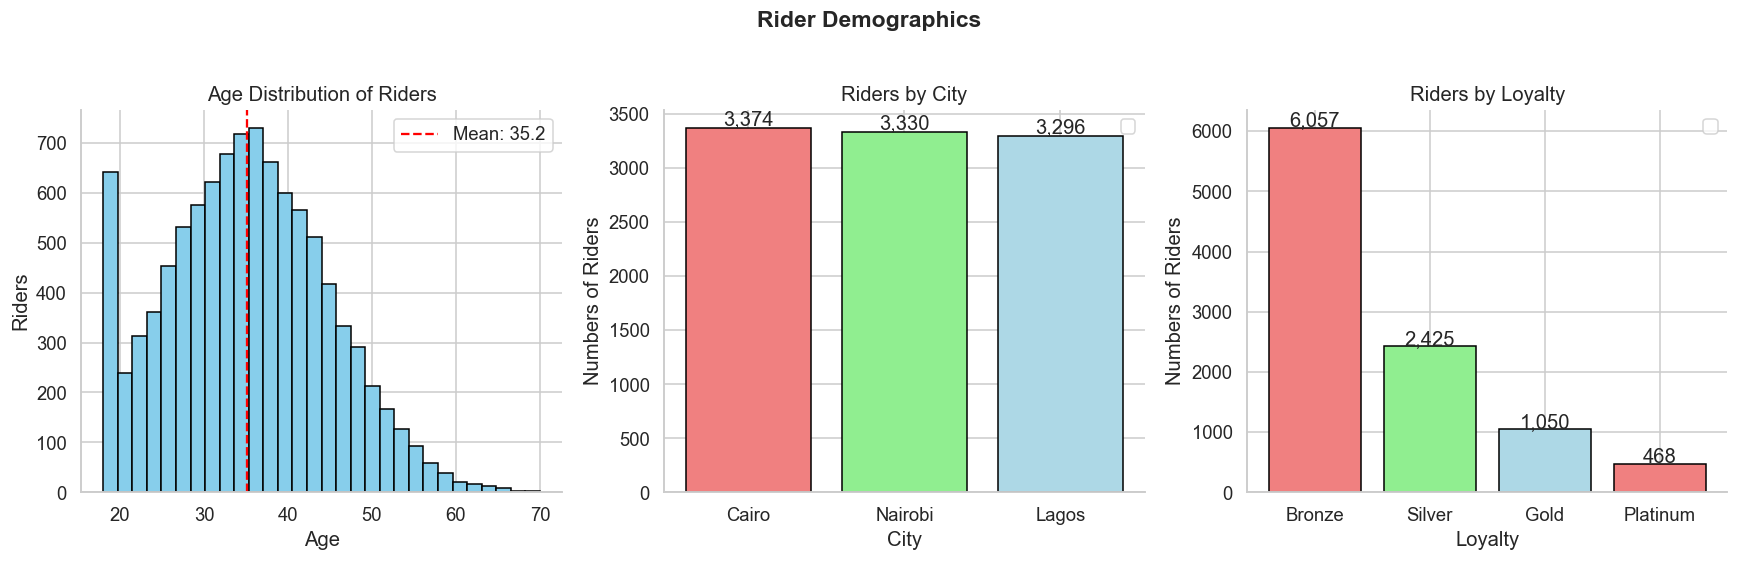

In [10]:
# 3a Age distribution of riders (configure the figure)
# define the figure size and style
fig , axes= plt.subplots(figsize=(16,5), nrows=1, ncols=3)

# 3b plot the age distribution(18-30, 30-50, 50+)
axes[0].hist(riders["age"].dropna(),bins=30,color="skyblue", edgecolor="black")
axes[0].axvline(riders["age"].mean(),color="red",linestyle="dashed",label=f"Mean: {riders['age'].mean():.1f}")


# step 3c configure the plot
axes[0].set_title("Age Distribution of Riders")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Riders")
axes[0].legend()

###############################################  PART 2####################################
# step 3d City Diistribution
city_counts= riders["city"].value_counts()

# 3e Plot the city Distribution
axes[1].bar(city_counts.index,city_counts.values, color=["lightcoral","lightgreen","lightblue"], edgecolor="black")


# step 3f configure the plot
for i, v in enumerate(city_counts.values):
    axes[1].text(i, v +30, f"{v:,}", ha="center")
axes[1].set_title("Riders by City")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Numbers of Riders")
axes[1].legend()


##############################################  PART 3 ###################################
# step 3g Plot Loyalty Distribution
loyalty_counts= riders["loyalty_status"].value_counts()

#step 3h  configure the plot 
axes[2].bar(loyalty_counts.index,loyalty_counts.values, color=["lightcoral","lightgreen","lightblue"], edgecolor="black")

# 3i configure the plot 
for i, v in enumerate(loyalty_counts.values):
    axes[2].text(i, v +30, f"{v:,}", ha="center")
axes[2].set(title="Riders by Loyalty",xlabel="Loyalty",ylabel="Numbers of Riders")

axes[2].legend()

plt.suptitle("Rider Demographics", fontsize=15, fontweight="bold",y=1.02)
plt.tight_layout()
plt.show()



### STEP 4 churn Probability Column

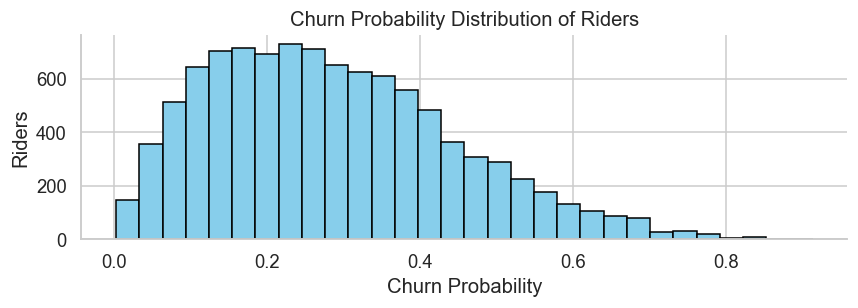

In [11]:
fig, ax= plt.subplots(figsize= (8,3))
ax.hist(riders["churn_prob"].dropna(),bins=30,color="skyblue", edgecolor="black")
ax.set(title="Churn Probability Distribution of Riders",xlabel="Churn Probability",ylabel="Riders")

plt.tight_layout()
plt.show()


### Step 5 Sign up Trend Overtime

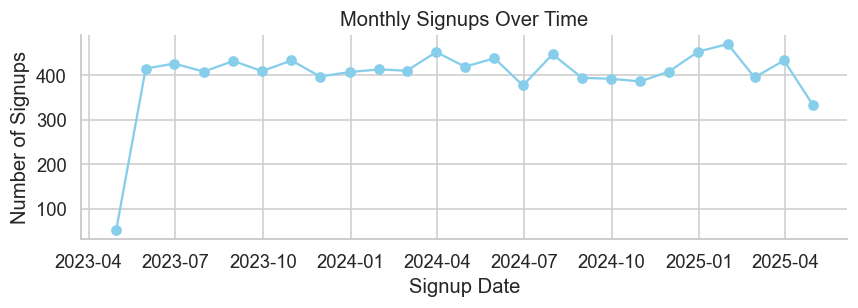

In [12]:
monthly = riders.set_index("signup_date").resample("ME").size().reset_index(name="signups")

fig, ax = plt.subplots(figsize=(8,3))
ax.plot(monthly["signup_date"], monthly["signups"], marker="o", color="skyblue")
ax.set(title="Monthly Signups Over Time", xlabel="Signup Date", ylabel="Number of Signups")
plt.tight_layout()
plt.show()

### Step 6 Trip Analysis

In [13]:
trips.head()
print(f"Shape : {trips.shape}")
print(trips.dtypes)
print(trips.isnull().sum())

Shape : (200000, 16)
trip_id              object
user_id              object
driver_id            object
fare                float64
surge_multiplier    float64
tip                 float64
payment_type         object
pickup_time          object
dropoff_time         object
pickup_lat          float64
pickup_lng          float64
dropoff_lat         float64
dropoff_lng         float64
weather              object
city                 object
loyalty_status       object
dtype: object
trip_id             0
user_id             0
driver_id           0
fare                0
surge_multiplier    0
tip                 0
payment_type        0
pickup_time         0
dropoff_time        0
pickup_lat          0
pickup_lng          0
dropoff_lat         0
dropoff_lng         0
weather             0
city                0
loyalty_status      0
dtype: int64


#### Step 6a Converted To Proper Date Format

In [14]:
# fix timestamps
for col in ["pickup_time", "dropoff_time"]:
    trips[col] = pd.to_datetime(trips[col],  utc=True, errors="coerce").dt.tz_localize(None)



#### 6b Engineered Trip Features

In [15]:
#  1 - Calculate trip duration in minutes

#  pickup_time 
# dropoff_time

#  dropoff_time - pickup_time

#2 - Total Revenue
# fare * surge_multiplier + tip_amount
# segment high, medium, low cusomers

# hour of the day & day of the week
# 3  hour of the day of the week = pickup_time ad extract the hour 
#      .pickuo_time amd extract and extractday of the week

In [16]:
##    step 1---- duration of trips

trips["trip_duration_min"] = ((trips["dropoff_time"] - trips["pickup_time"]).dt.total_seconds() / 60
)

#step 1b ---- total revenue
trips["total_revenue"] = trips["fare"] * trips["surge_multiplier"]* trips["tip"].fillna(0)

# step 1c ---- hour of the day of the week
trips["hour_of_day"] = trips["pickup_time"].dt.hour
trips["day_of_week"] = trips["pickup_time"].dt.day_name()

###Step 6c Finamcial & Duration Distribution

. 1 Fare Distribution

. 2 Surge

. 3 Duration

Text(0.5, 1.02, 'Trips Financials & Duration Analysis')

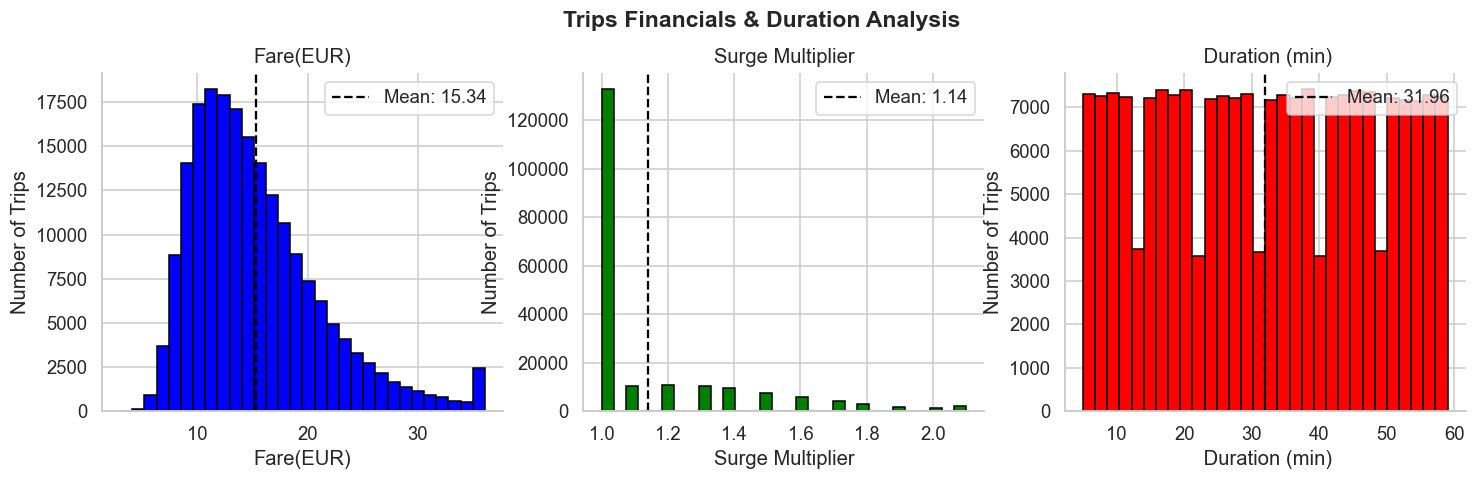

In [17]:
# Step 6ci - Distribution of trip duration
fig, axes = plt.subplots(1,3,figsize=(16,4))

for  ax, col, title, color in zip(
    axes,
    ["fare","surge_multiplier","trip_duration_min"],
    ["Fare(EUR)","Surge Multiplier"," Duration (min)"],
    ["blue","green","red"],):

# step 6cii - clip outliers at 99th percentile
    data = trips[col].clip(upper = trips[col].quantile(0.99)).dropna()

# step 6ciii - plot the distribution
    ax.hist(data, bins=30, color=color, edgecolor="black")
    ax.axvline(
        data.mean(), color="black", linestyle="dashed", label=f"Mean: {data.mean():.2f}"
    )
    ax.set(title=title, xlabel=title, ylabel="Number of Trips")
    ax.legend()
plt.suptitle("Trips Financials & Duration Analysis", fontsize=15, fontweight="bold", y=1.02)

#### Step 6d - Temporal Patterns: When Do People Ride

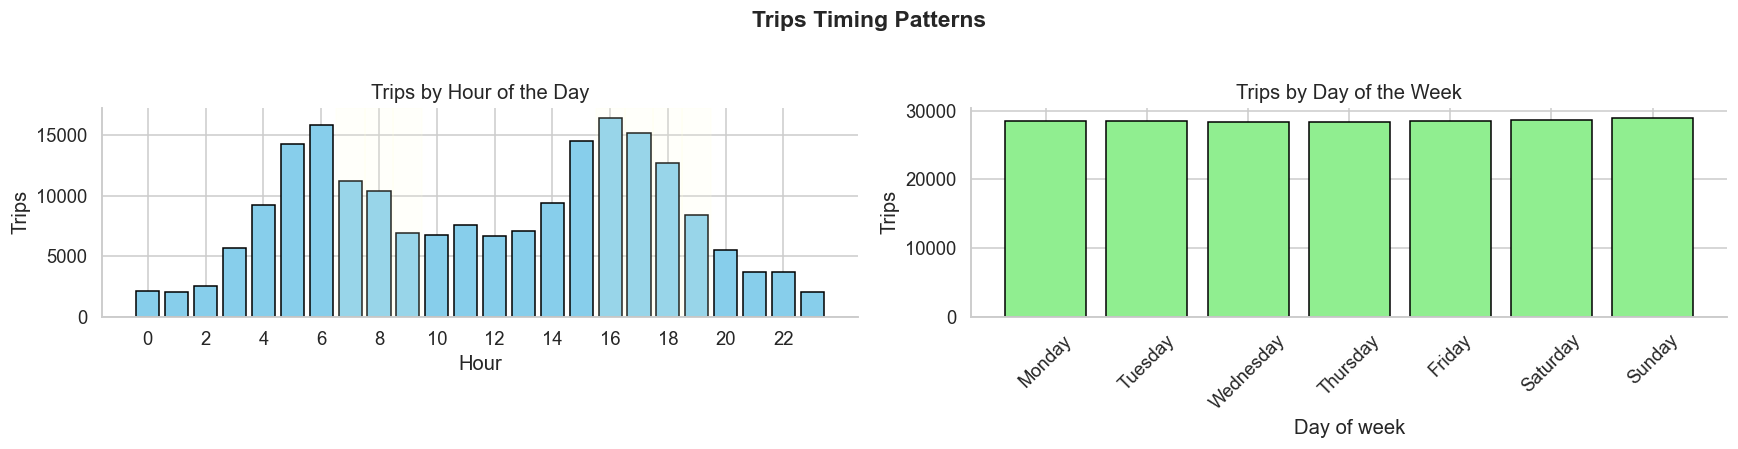

In [22]:

# Hour of the day & day of the week distribution

# Step 6di - Distribution of trips by hour of the day and day of the week
fig, axes = plt.subplots(1,2,figsize=(16,4))

# Step 6dii-Hour of the day distribution
hour_counts = trips["hour_of_day"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color="skyblue", edgecolor="black")

# Step 6diii -  Vertical Span to Highlight Rush hour 
for h in [7,8,9,16,17,18,19]:
    axes[0].axvspan(h-0.5, h+0.5, color="lightyellow", alpha=0.15)

axes[0].set(title="Trips by Hour of the Day", xlabel="Hour", ylabel="Trips")
axes[0].set_xticks(range(0,24,2))

# Step 6div - Day of the week distribution
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_counts = trips["day_of_week"].value_counts().reindex(day_order)

axes[1].bar(day_counts.index, day_counts.values, color=["lightgreen"], edgecolor="black")
axes[1].set(title="Trips by Day of the Week", xlabel="Day of week", ylabel="Trips")
axes[1].tick_params(axis="x",rotation=45)
 
plt.suptitle("Trips Timing Patterns", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6e - Payment & Weather Distribution

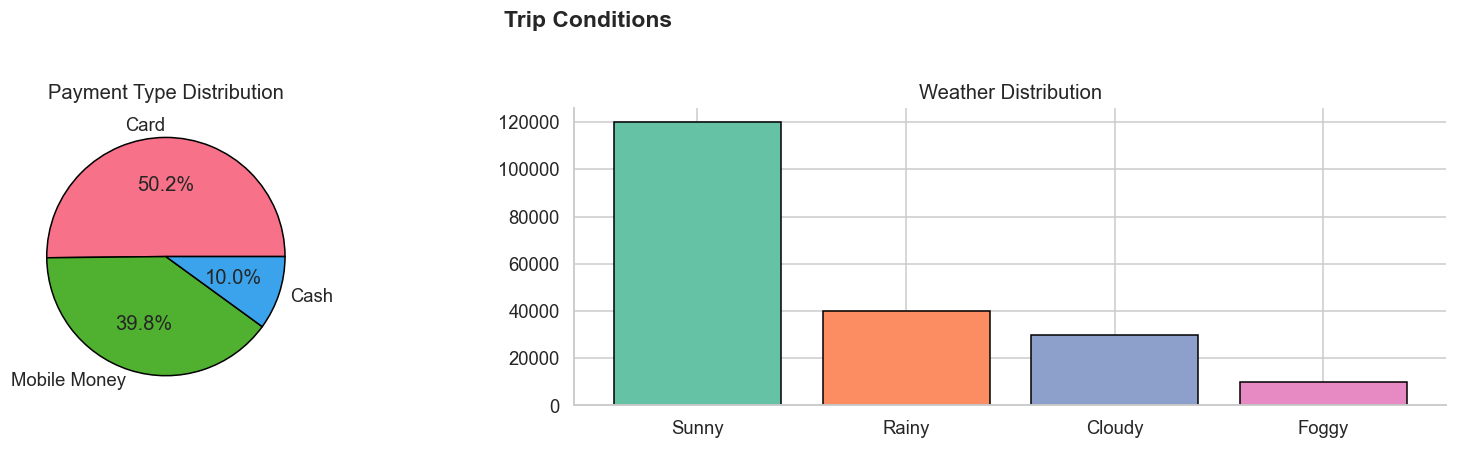

In [28]:
# payment type distribution
fig, axes = plt.subplots(1, 2, figsize=(16,4))
payment_counts = trips["payment_type"].value_counts()
axes[0].pie(payment_counts.values, labels=payment_counts.index, autopct="%1.1f%%", colors=sns.color_palette("husl",len(payment_counts)),wedgeprops={"edgecolor":"black"})

axes[0].set_title("Payment Type Distribution")


# weather distribution
weather_counts = trips["weather"].value_counts()
axes[1].bar(weather_counts.index, weather_counts.values, color=sns.color_palette("Set2",len(weather_counts)), edgecolor="black")
axes[1].set_title("Weather Distribution")

plt.suptitle("Trip Conditions", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### Step 7 - Drivers Dataset Analysis

In [29]:
drivers.head()

,driver_id,rating,vehicle_type,signup_date,last_active,city,acceptance_rate
0,D00000,3.1,SUV,2025-01-20,2025-01-06 18:23:09.312275,Cairo,0.679555
1,D00001,5.0,Sedan,2023-03-27,2025-04-27 01:44:02.472554,Nairobi,0.548786
2,D00002,4.5,Motorcycle,2024-05-02,2025-03-07 19:24:46.367672,Nairobi,0.593724
3,D00003,5.0,Motorcycle,2023-04-16,2025-03-26 19:16:24.253793,Nairobi,0.990000
4,D00004,4.4,Motorcycle,2023-05-28,2025-04-08 18:54:44.649615,Lagos,0.519773


In [30]:
print(f"Shape :{drivers.shape}")
print (drivers.dtypes)
print(drivers.isnull().sum())

Shape :(5000, 7)
driver_id                  object
rating                    float64
vehicle_type               object
signup_date        datetime64[ns]
last_active                object
city                       object
acceptance_rate           float64
dtype: object
driver_id          0
rating             0
vehicle_type       0
signup_date        0
last_active        0
city               0
acceptance_rate    0
dtype: int64


#### Step 7a Driver Fleet Composition

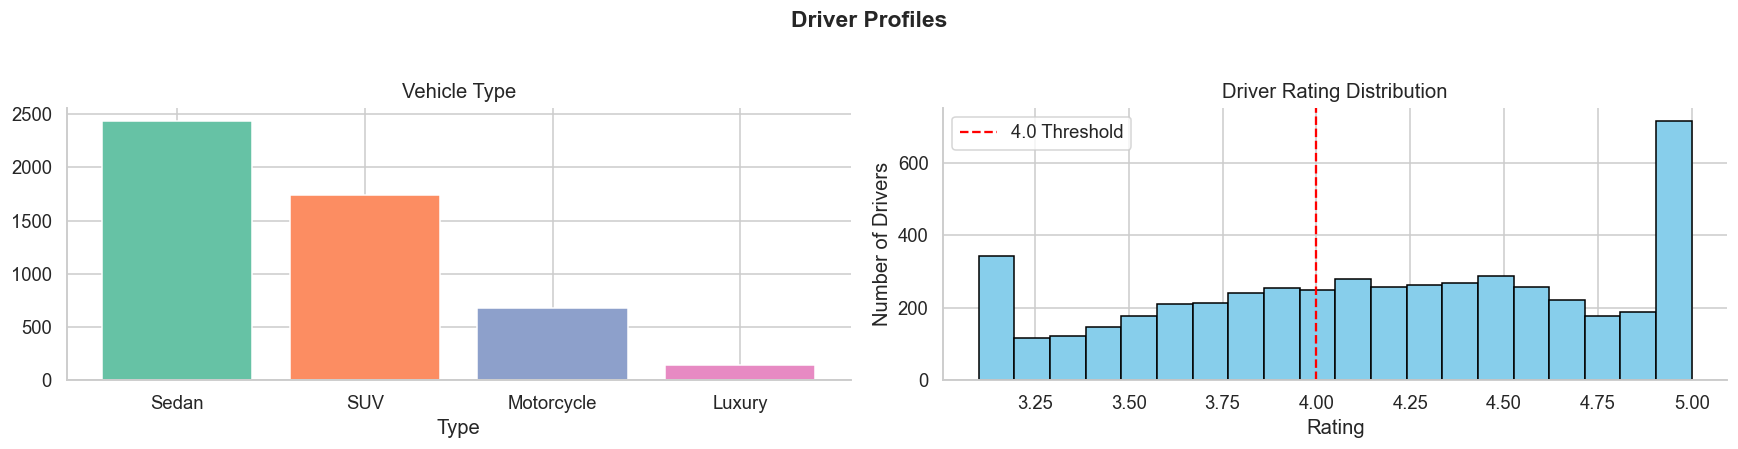

In [41]:
fig, axes= plt.subplots(1,2,figsize=(16,4))

# vehicle type 
vehicle_counts = drivers["vehicle_type"].value_counts()

axes[0].bar(
    vehicle_counts.index, vehicle_counts.values, 
    color=sns.color_palette("Set2",len(vehicle_counts)), edgecolor="white"
)

axes[0].set(title="Vehicle Type", xlabel="Type", ylabel="")

# Rate Distribution
axes[1].hist(drivers["rating"].dropna(), bins=20, color="skyblue", edgecolor="black")
axes[1].axvline(4.0, color="red", linestyle="dashed", label="4.0 Threshold")
axes[1].set(title="Driver Rating Distribution", xlabel="Rating", ylabel="Number of Drivers")
axes[1].legend()


plt.suptitle("Driver Profiles", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Step 8 - Session Dataset

In [42]:
sessions.head()

,session_id,rider_id,session_time,time_on_app,pages_visited,converted,city,loyalty_status
0,S000000,R08605,2025-04-27 18:57:06+02:05,79,4,1,Cairo,Bronze
1,S000001,R08823,2025-04-27 07:32:22+02:27,101,3,0,Nairobi,Silver
2,S000002,R05342,2025-04-27 23:17:25+02:05,12,1,0,Cairo,Bronze
3,S000003,R05057,2025-04-27 14:40:25+00:14,19,1,0,Lagos,Silver
4,S000004,R09614,2025-04-27 08:31:22+00:14,4,1,0,Lagos,Bronze


In [43]:
print(f"Shape : {sessions.shape}")
print(sessions.dtypes)
print(sessions.isnull().sum())

Shape : (50000, 8)
session_id        object
rider_id          object
session_time      object
time_on_app        int64
pages_visited      int64
converted          int64
city              object
loyalty_status    object
dtype: object
session_id        0
rider_id          0
session_time      0
time_on_app       0
pages_visited     0
converted         0
city              0
loyalty_status    0
dtype: int64


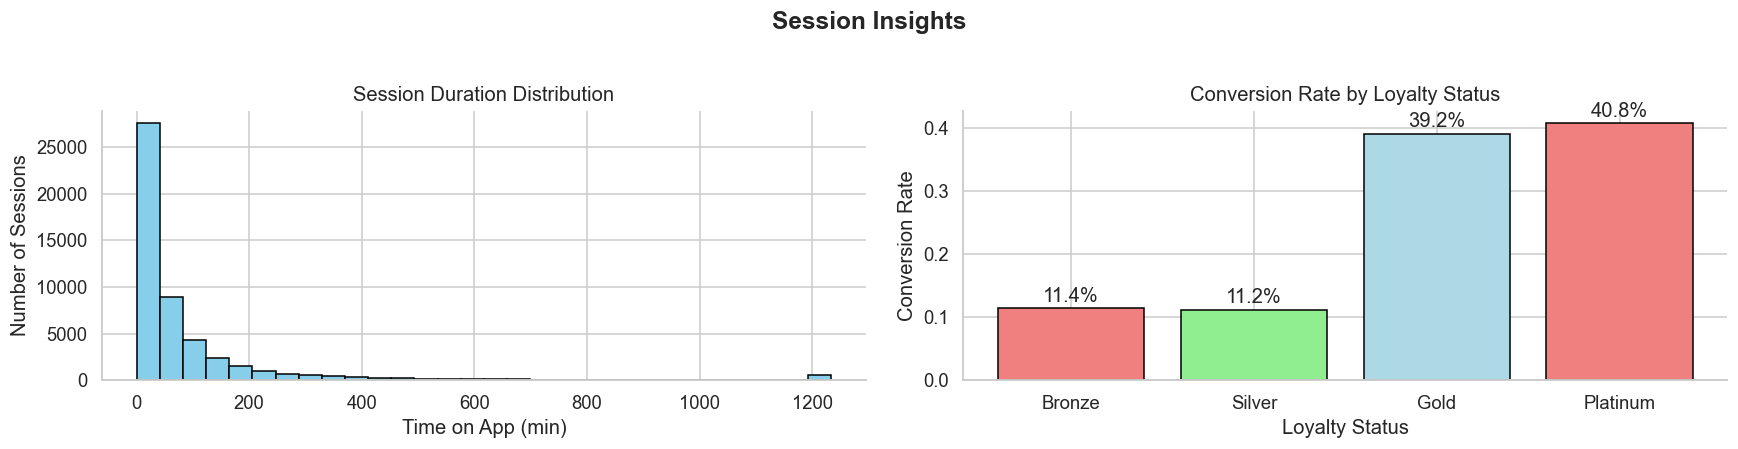

In [48]:
## session table analysis

fig, axes = plt.subplots(1,2,figsize=(16,4))

# session duration distribution
axes[0].hist(sessions["time_on_app"].clip(upper=sessions["time_on_app"].quantile(0.99)).dropna(), bins=30, color="skyblue", edgecolor="black")
axes[0].set(title="Session Duration Distribution", xlabel="Time on App (min)", ylabel="Number of Sessions")

## conversion rate by loyalty status
conv_loyalty = sessions.groupby("loyalty_status")["converted"].mean().reindex(["Bronze", "Silver", "Gold", "Platinum"])
axes[1].bar(conv_loyalty.index, conv_loyalty.values, color=["lightcoral","lightgreen","lightblue"], edgecolor="black")

for i, v in enumerate(conv_loyalty.values):
    axes[1].text(i, v +0.01, f"{v:.1%}", ha="center")
axes[1].set(title="Conversion Rate by Loyalty Status", xlabel="Loyalty Status", ylabel="Conversion Rate")


plt.suptitle("Session Insights", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Step 9- Churn Analysis

In [ ]:
riders["churn_prob"].head()

#  Define  a Threshold for churn
# churned  = 1 if churn_prob > 0.5
# not churned = 0 if churn_prob <= 0.5

0    0.142431
1    0.674161
2    0.510379
3    0.244779
4    0.269960
Name: churn_prob, dtype: float64

In [53]:
#  Engineer a new column "churned" based on the threshold
riders["churned"] = (riders["churn_prob"] > 0.5).astype(int)

# calculate and print overall churn rate and total churned riders
print(f"Overall Churn rate: {riders['churned'].mean()*100:.2f}%")
print(f"churned : {riders['churned'].sum()}")

Overall Churn rate: 10.63%
churned : 1063


#### Step 9b
1 - converted our churn column to binary label
0.123, 0.345, 0.23 --------- Continuous probabaility AKA decimels 
0,1,o,1 ------binary lasbel

2 - create a threshold =  0.5: Standard decsion boundary (>50% riders likely to churn = churned)
capp who churned and who didnt churn to binary label (0,1)

3 - churned = 1 if the peson's prob on the data is > 0.5
3b - not churned = 0 if the person's prob on the data is <= 0.5

#### Step 9c - Distribution of churn by Loyalty or  City (Bi- Variate Analysis)

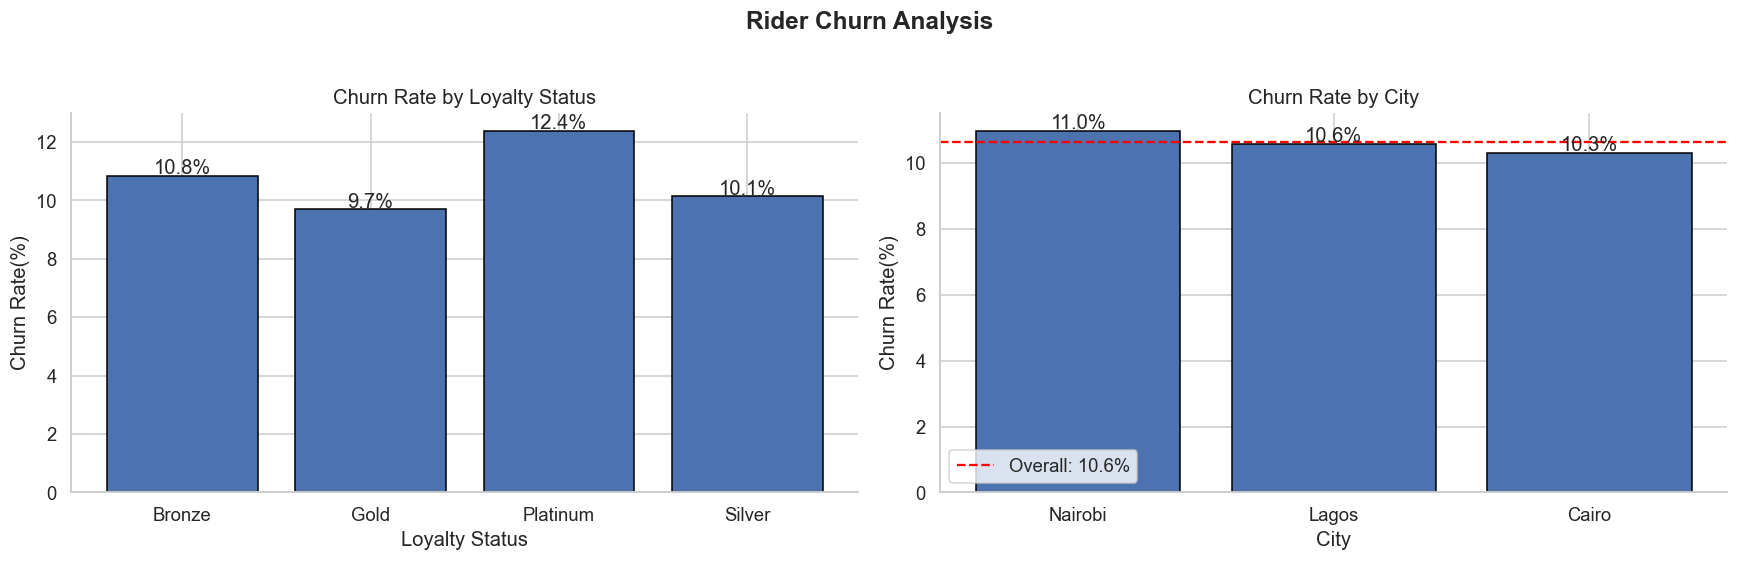

In [65]:
fig, axes= plt.subplots(1,2,figsize= (16,5))

# churn by loyalty status
churn_loyalty = riders.groupby("loyalty_status")["churned"].mean()*100
axes[0].bar(churn_loyalty.index, churn_loyalty.values, edgecolor="black",)

# annotate the bars with churn rates
for i, v in enumerate(churn_loyalty.values):
    axes[0].text(i, v +0.05, f"{v:.1f}%", ha="center")
axes[0].set(title="Churn Rate by Loyalty Status", xlabel="Loyalty Status", ylabel="Churn Rate(%)")


# Churn by city
churn_city =(riders.groupby("city")["churned"].mean()*100).sort_values(ascending =False)
overall = riders["churned"].mean() * 100

# Bar Plot 
axes[1].bar(churn_city.index, churn_city.values, edgecolor="black")
axes[1].axhline(overall, color="red", linestyle="dashed", label=f"Overall: {overall:.1f}%")

# annotate the bars with churn rates
for i, v in enumerate(churn_city.values):
    axes[1].text(i, v +0.05, f"{v:.1f}%", ha="center")
axes[1].set(title="Churn Rate by City", xlabel="City", ylabel="Churn Rate(%)")
axes[1].legend()

plt.suptitle("Rider Churn Analysis", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### Step 9d - Churn Analysis Final 

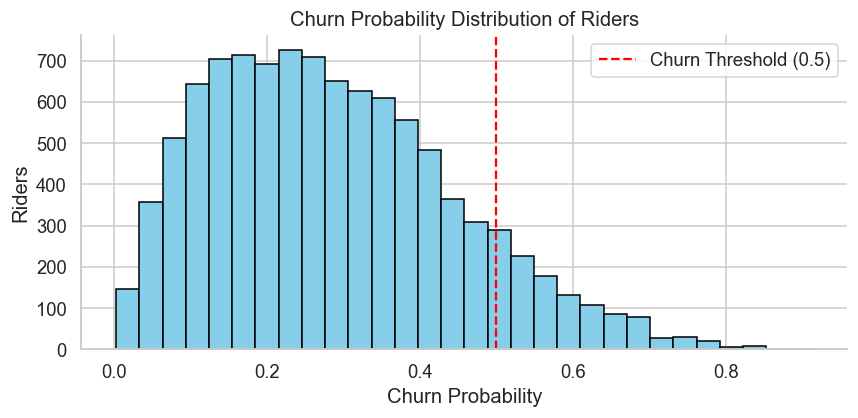

In [67]:
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(riders["churn_prob"].dropna(),bins=30,color="skyblue", edgecolor="black")

ax.axvline(0.5, color="red", linestyle="dashed", label="Churn Threshold (0.5)")
ax.set(title="Churn Probability Distribution of Riders", xlabel="Churn Probability", ylabel="Riders")

ax.legend()
plt.tight_layout()
plt.show()

In [70]:
riders.columns

Index(['user_id', 'signup_date', 'loyalty_status', 'age', 'city',
       'avg_rating_given', 'churn_prob', 'referred_by', 'churned'],
      dtype='object')